# Vanilla HNSW

In [1]:
import struct
import numpy as np
import torch
import torch.nn.functional as F
import heapq
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt

def read_fvecs(path: str) -> np.ndarray:
    """Read .fvecs file into (N, d) float32 array."""
    with open(path, 'rb') as f:
        vecs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            d = struct.unpack('i', hdr)[0]
            data = struct.unpack('f' * d, f.read(4 * d))
            vecs.append(data)
    return np.vstack(vecs).astype('float32')


def read_ivecs(path: str) -> np.ndarray:
    """Read .ivecs file into (N, k) int array."""
    with open(path, 'rb') as f:
        idxs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            k = struct.unpack('i', hdr)[0]
            data = struct.unpack('i' * k, f.read(4 * k))
            idxs.append(data)
    return np.vstack(idxs).astype('int64')

# ----------------------------
# Select GPU or CPU
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(device)

device(type='cuda')

In [2]:
class HNSWIndexTorch:
    def __init__(self, M=16, ef_construction=200, ef_search=200,
                 metric='l2', device=None):
        """
        M: max neighbors per node
        ef_construction: candidate pool size during construction
        ef_search: pool size during search
        metric: 'l2' or 'cosine'
        """
        self.M = M
        self.ef_construction = ef_construction
        self.ef_search = ef_search
        self.metric = metric
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # will be set in fit()
        self.data = None              # torch.Tensor (N, d)
        self.levels = []              # list of dict {'nodes': [...], 'neighbors': {...}}
        self.max_level = 0
        self.entry_point = None

    def _distance_batch(self, q: torch.Tensor, pts: torch.Tensor) -> torch.Tensor:
        # q: (d,), pts: (n, d)
        if self.metric == 'l2':
            return torch.norm(pts - q.unsqueeze(0), dim=1)
        # cosine distance
        qn = F.normalize(q.unsqueeze(0), dim=1)
        pn = F.normalize(pts, dim=1)
        return 1 - (qn @ pn.t()).squeeze(0)

    def _dist_scalar(self, a: int, b: int) -> float:
        # still only used sparingly (backlink eviction)
        if self.metric == 'l2':
            return float(torch.norm(self.data[a] - self.data[b]).item())
        return float(1 - torch.dot(self.data[a], self.data[b]).item())

    def _select_diverse(self,
                        cand_idxs: torch.Tensor,
                        cand_dists: torch.Tensor,
                        M: int) -> list:
        """
        Vectorized greedy diversify on GPU.
        cand_idxs: (K,) tensor of candidate node indices
        cand_dists: (K,) tensor of their distances to the query
        """
        selected = []
        device = cand_idxs.device

        for _ in range(M):
            if len(selected) == 0:
                # pick global min
                _, argmin = cand_dists.min(dim=0)
                sel = int(cand_idxs[argmin].item())
            else:
                sel_tensor = torch.tensor(selected, device=device)       # (S,)
                pts_cand = self.data[cand_idxs]                          # (K, d)
                pts_sel  = self.data[sel_tensor]                          # (S, d)
                # all pairwise distances: (K, S)
                d_cs = torch.cdist(pts_cand, pts_sel, p=2)
                min_d_cs, _ = d_cs.min(dim=1)                             # (K,)

                # enforce diversification: min_d_cs >= cand_dists
                mask = min_d_cs >= cand_dists
                valid = cand_dists.clone()
                valid[~mask] = float('inf')

                _, argmin = valid.min(dim=0)
                sel = int(cand_idxs[argmin].item())

            selected.append(sel)

            # remove sel from the candidate pool
            keep = cand_idxs != sel
            cand_idxs  = cand_idxs[keep]
            cand_dists = cand_dists[keep]
            if cand_idxs.numel() == 0:
                break

        # if fewer than M, pad with next-best
        if len(selected) < M and cand_idxs.numel() > 0:
            need = M - len(selected)
            _, argmins = cand_dists.topk(k=need, largest=False)
            selected.extend([int(x.item()) for x in cand_idxs[argmins]])

        return selected

    def fit(self, data_np: np.ndarray):
        """Build the HNSW index on GPU."""
        # load data
        pts = torch.from_numpy(data_np).to(self.device)
        if self.metric == 'cosine':
            pts = F.normalize(pts, dim=1)
        self.data = pts
        N, d = pts.shape

        # assign levels (geom. distribution)
        levels = torch.from_numpy(
            np.random.geometric(1.0 - 1.0/self.M, size=N) - 1
        ).to(self.device)
        self.max_level = int(levels.max().item())

        # init layers
        self.levels = [
            {'nodes': [], 'neighbors': {}} for _ in range(self.max_level + 1)
        ]

        # incremental insertion
        for i in tqdm(range(N), desc='HNSW build'):
            lvl = int(levels[i].item())
            qi = pts[i]
            for layer in range(lvl + 1):
                lyr = self.levels[layer]
                nodes = lyr['nodes']
                if not nodes:
                    nodes.append(i)
                    lyr['neighbors'][i] = []
                    continue

                # compute distances to existing nodes in batch
                node_tensor = torch.tensor(nodes, device=self.device)
                dists = self._distance_batch(qi, pts[node_tensor])         # (len(nodes),)

                # pick top ef_construction candidates
                k = min(self.ef_construction, len(nodes))
                vals, inds = torch.topk(dists, k=k, largest=False)
                cand_idxs  = node_tensor[inds]                              # (k,)
                cand_dists = vals                                           # (k,)

                # diversify-select M on GPU
                selected = self._select_diverse(cand_idxs, cand_dists, self.M)

                # store neighbors & backlink
                lyr['neighbors'][i] = selected
                for j in selected:
                    nbrs_j = lyr['neighbors'].setdefault(j, [])
                    if len(nbrs_j) < self.M:
                        nbrs_j.append(i)
                    else:
                        # evict worst if needed
                        nbrs_tensor = torch.tensor(nbrs_j, device=self.device)
                        d_j = self._distance_batch(pts[j], pts[nbrs_tensor])
                        worst_idx = int(d_j.argmax().item())
                        worst_node = nbrs_j[worst_idx]
                        dist_i_j = self._dist_scalar(i, j)
                        if dist_i_j < d_j[worst_idx].item():
                            nbrs_j[worst_idx] = i
                    lyr['neighbors'][j] = nbrs_j

                nodes.append(i)

        # pick entry point: node in top layer closest to centroid
        cent = pts.mean(dim=0)
        top_nodes = self.levels[self.max_level]['nodes']
        top_tensor = torch.tensor(top_nodes, device=self.device)
        d_top = self._distance_batch(cent, pts[top_tensor])
        best_i = int(d_top.argmin().item())
        self.entry_point = top_nodes[best_i]

    def search(self, query_np: np.ndarray, k=10) -> list:
        """k-NN search with HNSW."""
        q = torch.from_numpy(query_np).to(self.device)
        if self.metric == 'cosine':
            q = F.normalize(q, dim=0)

        ep = self.entry_point
        # 1) greedy descent
        for layer in range(self.max_level, 0, -1):
            nodes = self.levels[layer]['nodes']
            nbrmap = self.levels[layer]['neighbors']
            if ep not in nodes:
                node_tensor = torch.tensor(nodes, device=self.device)
                dists = self._distance_batch(self.data[ep], self.data[node_tensor])
                ep = int(node_tensor[dists.argmin()].item())

            improved = True
            while improved:
                improved = False
                nbrs = nbrmap[ep]
                if not nbrs:
                    break
                nbr_pts = self.data[nbrs]
                d_n = self._distance_batch(q, nbr_pts)
                best_i = int(d_n.argmin().item())
                if d_n[best_i].item() < self._distance_batch(q, self.data[ep:ep+1]).item():
                    ep = nbrs[best_i]
                    improved = True

        # 2) best-first search on layer 0
        visited = {ep}
        C = [(float(self._distance_batch(q, self.data[ep:ep+1])), ep)]
        W = [(-C[0][0], ep)]

        while C:
            dist_u, u = heapq.heappop(C)
            worst_dist = -W[0][0]
            if len(W) >= self.ef_search and dist_u > worst_dist:
                break
            for v in self.levels[0]['neighbors'][u]:
                if v in visited:
                    continue
                visited.add(v)
                dv = float(self._distance_batch(q, self.data[v:v+1]))
                if len(W) < self.ef_search or dv < worst_dist:
                    heapq.heappush(C, (dv, v))
                    heapq.heappush(W, (-dv, v))
                    if len(W) > self.ef_search:
                        heapq.heappop(W)
                    worst_dist = -W[0][0]

        result = [node for (_, node) in W]
        result.sort(key=lambda node: float(self._distance_batch(q, self.data[node:node+1])))
        return result[:k]

def recall_at_k(preds, gt, k=10):
    hits = 0
    n = len(preds)
    for i in range(n):
        hits += len(set(preds[i][:k]) & set(gt[i][:k]))
    print(hits)
    return hits / (n * k)

In [3]:
class AE(nn.Module):
    def __init__(self, D=128, D_latent=32, dropout=0.1):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(D, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, D_latent)
        )
        self.dec = nn.Sequential(
            nn.Linear(D_latent, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, D)
        )

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

def train_ae(base_np, gt_base, knn_bb, D_latent, device, epochs=20, batch_size=256, lr=1e-3, wd=1e-5, margin=0.2, tri_w=1.0):
    """
    Trains an autoencoder with MSE + triplet loss.

    base_np:   (N, D) numpy array of base vectors
    D_latent:  dimensionality of the bottleneck
    device:    torch device
    epochs:    training epochs
    batch_size: batch size
    lr:        learning rate
    wd:        weight decay
    margin:    triplet margin
    tri_w:     weight on the triplet loss
    """
    # Dataset with indices so we can sample positives/negatives
    idxs = torch.arange(len(base_np))
    ds = TensorDataset(torch.from_numpy(base_np).float(), idxs)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    # Build AE
    ae = AE(D=base_np.shape[1], D_latent=D_latent).to(device)
    opt = optim.Adam(ae.parameters(), lr=lr, weight_decay=wd)

    for epoch in range(epochs):
        total_rec = 0.0
        total_tri = 0.0
        for (x, idx_tensor) in loader:
            x = x.to(device)
            idx = idx_tensor.cpu().numpy()  # indices into base_np

            # Forward pass
            recon, z_q = ae(x)
            # Reconstruction loss
            loss_rec = ((recon - x)**2).mean()

            # --- Triplet loss computation ---
            # Sample one positive and one negative per example
            # --- Triplet loss computation ---
            pos_idx = []
            neg_idx = []
            N = base_np.shape[0]
            for qi in idx: 
                # positive = random true neighbor
                p = np.random.choice(gt_base[qi])
                # negative = random *hard* negative
                n = np.random.choice(knn_bb[qi])
                pos_idx.append(p)
                neg_idx.append(n)


            # Gather their tensors
            xp = torch.from_numpy(base_np[pos_idx]).float().to(device)
            xn = torch.from_numpy(base_np[neg_idx]).float().to(device)
            # Encode positives & negatives
            _, z_p = ae(xp)
            _, z_n = ae(xn)

            # Compute distances
            d_pos = (z_q - z_p).pow(2).sum(dim=1)
            d_neg = (z_q - z_n).pow(2).sum(dim=1)
            # Triplet loss
            loss_tri = F.relu(d_pos - d_neg + margin).mean()

            # Total loss
            loss = loss_rec + tri_w * loss_tri

            # Backprop
            opt.zero_grad()
            loss.backward()
            opt.step()

            total_rec += loss_rec.item()
            total_tri += loss_tri.item()

        avg_rec = total_rec / len(loader)
        avg_tri = total_tri / len(loader)
        print(f"[AE] Epoch {epoch+1}/{epochs} — MSE={avg_rec:.4e}, Triplet={avg_tri:.4e}")

    return ae


def encode(ae, data_np, device, batch_size=256):
    ae.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(data_np).float()), batch_size=batch_size)
    latents = []
    with torch.no_grad():
        for (x,) in loader:
            z = ae.enc(x.to(device)).cpu().numpy()
            latents.append(z)
    return np.vstack(latents)


In [4]:
from sklearn.neighbors import NearestNeighbors

# 1) Load & truncate as before
base  = read_fvecs('siftsmall/siftsmall_base.fvecs')
query = read_fvecs('siftsmall/siftsmall_query.fvecs')
gt    = read_ivecs('siftsmall/siftsmall_groundtruth.ivecs')

N = 1000
base = base[:N]

# 2) query→base ground truth (gt2)
#    exact top‑10 ℓ₂ neighbors for every query
nn_qb = NearestNeighbors(
    n_neighbors=10,
    algorithm='brute',
    metric='euclidean',
    n_jobs=-1
)
nn_qb.fit(base)
# distances_qb: (n_query,10), gt2: (n_query,10)
distances_qb, gt2 = nn_qb.kneighbors(query)


# 3) base→base GT for triplet training
#    we ask for 51 neighbors so that the first is self (0‑dist)
#    and the next 50 give us positives+negatives
nn_bb = NearestNeighbors(
    n_neighbors=51,
    algorithm='brute',
    metric='euclidean',
    n_jobs=-1
)
nn_bb.fit(base)
dists_bb, idxs_bb = nn_bb.kneighbors(base)

# drop the self‑match in column 0:
#   gt_base: true 10 NN excluding self
#   knn_bb: next 50 for hard negatives
gt_base = idxs_bb[:, 1:11]   # shape (N,10)
knn_bb  = idxs_bb[:, 1:51]   # shape (N,50)

# 4) Settings to sweep
latent_dims = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
rerank_flags = [False, True]

results = []  # (mode, D_latent, rerank, recall, build_t, query_t, rerank_t)

# 5)  Baseline: raw HNSW
for rerank in rerank_flags:
    start = time.time()
    idx_raw = HNSWIndexTorch(M=32, ef_construction=200, ef_search=400, metric='l2', device=device)
    idx_raw.fit(base)
    build_t = time.time() - start

    # query
    t_q = t_r = 0.0
    preds = []
    for q in tqdm(query, desc=f"Query Raw rerank={rerank}"):
        t0 = time.time()
        cand = idx_raw.search(q, k=50)
        t_q += time.time() - t0
        if rerank:
            t0 = time.time()
            # re-rank in full 128-D
            dists = np.linalg.norm(base[cand] - q, axis=1)
            cand = list(np.array(cand)[np.argsort(dists)[:10]])
            t_r += time.time() - t0
        else:
            cand = cand[:10]
        preds.append(cand)
    rec = recall_at_k(preds, gt2, k=10)
    results.append(("raw", None, rerank, rec, build_t, t_q, t_r))

# 6) Learned compressor + HNSW
for D_latent in latent_dims:
    # a) train
    # instead of train_ae(base, gt2, ...)
    ae = train_ae(base, gt_base, knn_bb,
            D_latent, device,
            epochs=20, batch_size=256,
            lr=5e-4, wd=1e-6,
            margin=1.0, tri_w=1.0)


    # b) encode
    base_lat = encode(ae, base, device)
    query_lat= encode(ae, query, device)

    for rerank in rerank_flags:
        start = time.time()
        idx_lat = HNSWIndexTorch(M=32, ef_construction=200, ef_search=400, metric='l2', device=device)
        idx_lat.fit(base_lat)
        build_t = time.time() - start

        t_q = t_r = 0.0
        preds = []
        for i,qz in enumerate(tqdm(query_lat, desc=f"Query Lat{D_latent} rerank={rerank}")):
            t0 = time.time()
            cand = idx_lat.search(qz, k=50)
            t_q += time.time() - t0
            if rerank:
                t0 = time.time()
                dists = np.linalg.norm(base[cand] - query[i], axis=1)
                cand = list(np.array(cand)[np.argsort(dists)[:10]])
                t_r += time.time() - t0
            else:
                cand = cand[:10]
            preds.append(cand)
        rec = recall_at_k(preds, gt2, k=10)
        results.append(("latent", D_latent, rerank, rec, build_t, t_q, t_r))


Query Raw rerank=False: 100%|██████████| 100/100 [00:01<00:00, 61.38it/s]


1000


Query Raw rerank=True: 100%|██████████| 100/100 [00:01<00:00, 60.51it/s]


1000
[AE] Epoch 1/20 — MSE=2.0158e+03, Triplet=8.3230e-01
[AE] Epoch 2/20 — MSE=2.0114e+03, Triplet=8.3554e-01
[AE] Epoch 3/20 — MSE=2.0074e+03, Triplet=8.2852e-01
[AE] Epoch 4/20 — MSE=2.0035e+03, Triplet=8.0584e-01
[AE] Epoch 5/20 — MSE=1.9996e+03, Triplet=8.0986e-01
[AE] Epoch 6/20 — MSE=1.9957e+03, Triplet=8.0987e-01
[AE] Epoch 7/20 — MSE=1.9917e+03, Triplet=8.0526e-01
[AE] Epoch 8/20 — MSE=1.9876e+03, Triplet=7.9839e-01
[AE] Epoch 9/20 — MSE=1.9834e+03, Triplet=8.4289e-01
[AE] Epoch 10/20 — MSE=1.9792e+03, Triplet=8.4020e-01
[AE] Epoch 11/20 — MSE=1.9749e+03, Triplet=8.5520e-01
[AE] Epoch 12/20 — MSE=1.9706e+03, Triplet=8.7119e-01
[AE] Epoch 13/20 — MSE=1.9662e+03, Triplet=8.6376e-01
[AE] Epoch 14/20 — MSE=1.9618e+03, Triplet=8.9486e-01
[AE] Epoch 15/20 — MSE=1.9575e+03, Triplet=8.9976e-01
[AE] Epoch 16/20 — MSE=1.9533e+03, Triplet=8.8663e-01
[AE] Epoch 17/20 — MSE=1.9486e+03, Triplet=9.1365e-01
[AE] Epoch 18/20 — MSE=1.9441e+03, Triplet=8.8856e-01
[AE] Epoch 19/20 — MSE=1.9398e+0

Query Lat10 rerank=False: 100%|██████████| 100/100 [00:01<00:00, 64.38it/s]


...

816
[AE] Epoch 1/20 — MSE=2.0191e+03, Triplet=1.1643e+00
[AE] Epoch 2/20 — MSE=2.0138e+03, Triplet=1.2766e+00
[AE] Epoch 3/20 — MSE=2.0090e+03, Triplet=1.2379e+00
[AE] Epoch 4/20 — MSE=2.0047e+03, Triplet=1.0361e+00
[AE] Epoch 5/20 — MSE=2.0005e+03, Triplet=1.0766e+00
[AE] Epoch 6/20 — MSE=1.9964e+03, Triplet=9.3934e-01
[AE] Epoch 7/20 — MSE=1.9924e+03, Triplet=9.2035e-01
[AE] Epoch 8/20 — MSE=1.9883e+03, Triplet=8.7144e-01
[AE] Epoch 9/20 — MSE=1.9843e+03, Triplet=8.3209e-01
[AE] Epoch 10/20 — MSE=1.9802e+03, Triplet=8.2625e-01
[AE] Epoch 11/20 — MSE=1.9761e+03, Triplet=7.6461e-01
[AE] Epoch 12/20 — MSE=1.9720e+03, Triplet=6.9144e-01
[AE] Epoch 13/20 — MSE=1.9678e+03, Triplet=7.3705e-01
[AE] Epoch 14/20 — MSE=1.9636e+03, Triplet=7.7724e-01
[AE] Epoch 15/20 — MSE=1.9592e+03, Triplet=7.4047e-01
[AE] Epoch 16/20 — MSE=1.9549e+03, Triplet=6.4223e-01
[AE] Epoch 17/20 — MSE=1.9506e+03, Triplet=6.6208e-01
[AE] Epoch 18/20 — MSE=1.9460e+03, Triplet=6.9864e-01
[AE] Epoch 19/20 — MSE=1.9415e+03

Query Lat120 rerank=False: 100%|██████████| 100/100 [00:01<00:00, 61.00it/s]


372


Query Lat120 rerank=True: 100%|██████████| 100/100 [00:01<00:00, 64.69it/s]

779


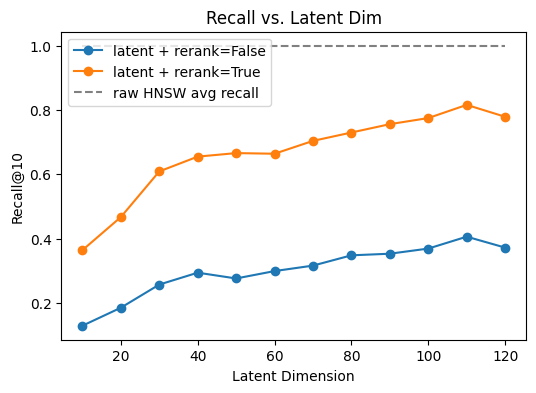

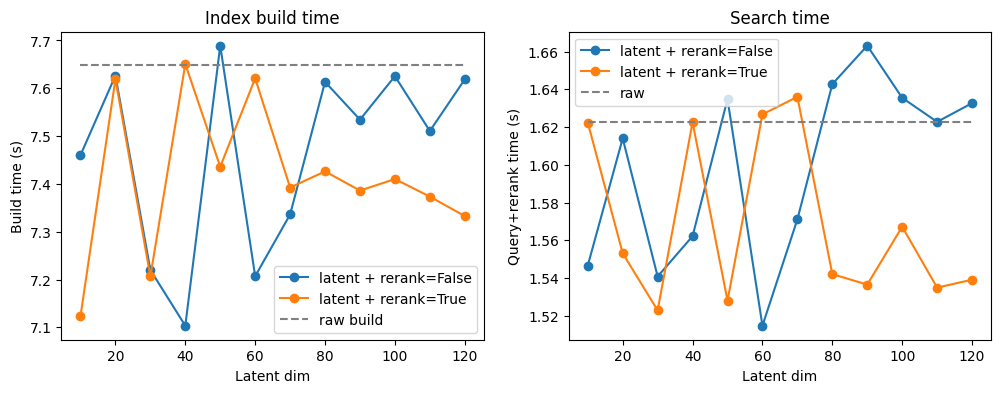

In [5]:
# 7) Plotting
import pandas as pd
# Build the DataFrame (as before)
df = pd.DataFrame(results, columns=[
    "mode","D_lat","rerank","recall","build","query","rerank_time"
])

# Plot Recall vs Latent Dimension
plt.figure(figsize=(6,4))
for rerank_flag in [False, True]:
    sub = df[(df["mode"]=="latent") & (df["rerank"]==rerank_flag)]
    plt.plot(sub["D_lat"], sub["recall"], marker='o',
            label=f"latent + rerank={rerank_flag}")

# Raw baseline: one line across all latent dims
raw_sub = df[df["mode"]=="raw"]
baseline = raw_sub["recall"].mean()
plt.hlines(baseline,
        xmin=min(latent_dims),
        xmax=max(latent_dims),
        linestyles='dashed',
        color='grey',
        label="raw HNSW avg recall")

plt.xlabel("Latent Dimension")
plt.ylabel("Recall@10")
plt.title("Recall vs. Latent Dim")
plt.legend()
plt.show()

# 2.1 Build & Query time vs latent dim
fig, ax = plt.subplots(1,2, figsize=(12,4))

# Build time:
for rer in [False, True]:
    sub = df[(df["mode"]=="latent") & (df["rerank"]==rer)]
    ax[0].plot(sub["D_lat"], sub["build"], marker='o', label=f"latent + rerank={rer}")
# raw baseline:
b_raw = df[df["mode"]=="raw"]["build"].mean()
ax[0].hlines(b_raw,
            xmin=min(latent_dims),
            xmax=max(latent_dims),
            linestyles='dashed',
            color='grey',
            label="raw build")
ax[0].set_xlabel("Latent dim")
ax[0].set_ylabel("Build time (s)")
ax[0].legend()
ax[0].set_title("Index build time")

# Query+re-rank time:
for rer in [False, True]:
    sub = df[(df["mode"]=="latent") & (df["rerank"]==rer)]
    total = sub["query"] + sub["rerank_time"]
    ax[1].plot(sub["D_lat"], total, marker='o', label=f"latent + rerank={rer}")

# compute raw baseline total_time per rerank
raw_df = df[df["mode"]=="raw"].copy()
raw_df["total_time"] = raw_df["query"] + raw_df["rerank_time"]
qr_raw = raw_df.groupby("rerank", as_index=False)["total_time"].mean()
baseline_time = qr_raw.loc[qr_raw["rerank"] == False, "total_time"].iloc[0]

ax[1].hlines(baseline_time,
            xmin=min(latent_dims),
            xmax=max(latent_dims),
            linestyles='dashed',
            color='grey',
            label="raw")
ax[1].set_xlabel("Latent dim")
ax[1].set_ylabel("Query+rerank time (s)")
ax[1].legend()
ax[1].set_title("Search time")

plt.show()